# Vlasov Equation — Theory & Computation Notebook

Covers the full content of *Kinetic and Fluid Dynamics of Collisionless Plasmas*.

**Sections:** §1 Derivation · §2 Poisson/Maxwell · §3 Moment Hierarchy · §4 Closures · §5 Langmuir Waves · §6 Landau Damping · §7 BGK/Schamel · §8 Numerics · §9 Solver (Landau) · §10 Two-Stream · §11 Bump-on-Tail

## Global Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.special import wofz
from scipy.interpolate import CubicSpline

plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3,
                     'font.size':11,'axes.titlesize':12,'lines.linewidth':2})
print("Imports OK.")


---
## §1 — The Vlasov Equation

### 1.1 Why Not Boltzmann?
The Boltzmann equation relies on binary collisions. In a plasma, the dominant Coulomb
interaction is long-range and collective. Vlasov (1938) replaced the collision term with
a self-consistent mean field, valid when the plasma parameter $\Lambda = n_0\lambda_D^3 \gg 1$.

### 1.2 Phase-Space Continuity → Vlasov Equation
Demanding particle conservation in any 6D volume $\mathcal{V}$:

$$\frac{\partial f}{\partial t} + \nabla_\mathbf{x}\cdot(\mathbf{v}f) + \nabla_\mathbf{v}\cdot\!\left(\frac{\mathbf{F}}{m}f\right) = 0$$

Since $\nabla_\mathbf{v}\cdot\mathbf{F}=0$ for the Lorentz force:

$$\boxed{\frac{\partial f}{\partial t} + \mathbf{v}\cdot\nabla_\mathbf{x}f + \frac{q}{m}(\mathbf{E}+\mathbf{v}\times\mathbf{B})\cdot\nabla_\mathbf{v}f = 0}$$

### 1.3 Liouville's Theorem
$df/dt = 0$ along every trajectory — phase-space density is conserved like an incompressible fluid.
Any $f(H)$ (function of the Hamiltonian) is a stationary solution.

### Computation 1 — Maxwellian Equilibrium in Phase Space

In [ ]:
Nx, Nv = 200, 300
x = np.linspace(0, 4*np.pi, Nx)
v = np.linspace(-5, 5, Nv)
X, V = np.meshgrid(x, v, indexing='ij')

vth = 1.0
f0  = np.exp(-V**2/(2*vth**2)) / (np.sqrt(2*np.pi)*vth)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].pcolormesh(X, V, f0, cmap='plasma', shading='auto')
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$v/v_{th}$')
axes[0].set_title(r'Maxwellian $f_0(x,v)$ — uniform equilibrium')
plt.colorbar(im, ax=axes[0], label=r'$f_0$')

fv = f0[0,:]
axes[1].plot(v, fv, color='royalblue')
axes[1].fill_between(v, fv, alpha=0.25, color='royalblue')
axes[1].set_xlabel(r'$v/v_{th}$'); axes[1].set_ylabel(r'$f_0(v)$')
axes[1].set_title('Velocity marginal')
plt.tight_layout(); plt.show()

print(f"Integral of f0 over v = {np.trapezoid(fv,v):.6f}  (should be 1.0)")


---
## §2 — Vlasov-Poisson & Liouville's Theorem

### 2.1 Vlasov-Poisson System (electrostatic limit)

$$\nabla^2\phi(\mathbf{x},t) = -\frac{1}{\varepsilon_0}\sum_s q_s\int f_s\,d^3v, \qquad \mathbf{E}=-\nabla\phi$$

This self-consistent coupling is what makes the problem nonlinear.

### 2.2 Debye Screening

$$\phi(r)\propto\frac{1}{r}\exp(-r/\lambda_D), \qquad \lambda_D=\sqrt{\frac{\varepsilon_0 k_BT_e}{n_0 e^2}}$$

Beyond $\lambda_D$, electrostatic influence is exponentially suppressed.

### Computation 2 — Debye Screening

In [ ]:
eps0, kB, e = 8.854e-12, 1.381e-23, 1.602e-19

print("Plasma parameters:")
for n0, Te_eV in [(1e18,100),(1e19,200),(1e20,1000)]:
    Te  = Te_eV*e
    lD  = np.sqrt(eps0*Te/(n0*e**2))
    Lam = n0*lD**3
    print(f"  n={n0:.0e}, Te={Te_eV}eV  ->  lambda_D={lD*1e6:.2f} um,  Lambda={Lam:.1e}")

r = np.linspace(0.02, 6, 500)
phi_bare     = 1/r
phi_screened = np.exp(-r)/r   # normalised: r in units of lambda_D

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogy(r, phi_bare/phi_bare[0],     '--', color='tomato', label='Bare 1/r')
ax.semilogy(r, phi_screened/phi_screened[0], color='steelblue',
            label=r'Screened $e^{-r/\lambda_D}/r$')
ax.axvline(1, color='gray', ls=':', lw=1.5, label=r'$r=\lambda_D$')
ax.set_xlabel(r'$r/\lambda_D$'); ax.set_ylabel(r'$\phi$ (normalised)')
ax.set_title('Debye Screening'); ax.legend()
plt.tight_layout(); plt.show()


---
## §3 — Fluid Moment Hierarchy & Closure Problem

### 3.1 Moment Hierarchy
| Moment | Equation | New unknown |
|--------|----------|-------------|
| 0th ($n$) | $\partial_t n+\nabla\cdot(n\mathbf{u})=0$ | bulk velocity $\mathbf{u}$ |
| 1st ($mn\mathbf{u}$) | Momentum (plasma Navier-Stokes) | pressure tensor $\mathbf{P}$ |
| 2nd | Energy equation | heat flux $\mathbf{Q}$ |
| $N$-th | Depends on $(N+1)$-th moment | infinite chain! |

### 3.2 The Closure Problem
In a collisional gas ($K_n\ll1$), rapid collisions drive $f\to f_\text{Max}$, justifying truncation.
In a collisionless plasma ($K_n\gg1$), **no physical justification** exists.
Classical closures can predict heat flow in the **wrong direction**.

### Computation 3 — Velocity-Space Moments

In [ ]:
v  = np.linspace(-6,6,1000)
f  = np.exp(-v**2/2)/np.sqrt(2*np.pi)

n = np.trapezoid(f, v)
u = np.trapezoid(v*f, v)/n
T = np.trapezoid((v-u)**2*f, v)/n
print(f"n={n:.4f} (expect 1), u={u:.4f} (expect 0), T={T:.4f} (expect 1)")

fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, w, lab, col in zip(axes,
        [np.ones_like(v), v, (v-u)**2],
        [r'$1\to$ density', r'$v\to$ bulk flow', r'$(v-u)^2\to$ temperature'],
        ['steelblue','darkorange','seagreen']):
    ax.plot(v, f, 'k--', lw=1.2, label=r'$f(v)$')
    ax.plot(v, w*f, color=col); ax.fill_between(v,w*f,alpha=0.2,color=col)
    ax.set_xlabel(r'$v/v_{th}$'); ax.set_title(lab); ax.legend(fontsize=8)
plt.suptitle('Velocity-Space Moments of the Maxwellian',fontsize=13)
plt.tight_layout(); plt.show()


---
## §4 — Specialized Fluid Closures

### 4.1 Grad's 13-Moment Method
Expands $f$ around a local Maxwellian via Hermite polynomials. The 13 moments are:
density (1), momentum (3), pressure tensor (6), heat flux (3).

**Limitation:** Polynomial corrections can become **negative** at large peculiar velocities $|\mathbf{C}|$.

### 4.2 CGL Double-Adiabatic Theory (magnetised plasmas)
Replaces isotropic $p$ with gyrotropic tensor: $\mathbf{P}=p_\parallel\hat{b}\hat{b}+p_\perp(\mathbf{I}-\hat{b}\hat{b})$.
Closed by two adiabatic invariants ($\mu\propto p_\perp/\rho B$, $J\propto p_\parallel B^2/\rho^3$).

**Limitation:** Assumes zero parallel heat flux — completely misses Landau damping.

### 4.3 Hammett-Perkins Landau Fluid Closure
Mimics kinetic plasma dispersion function via non-local heat flux:

$$\tilde{q}_\parallel = -n_0\chi_1\frac{\sqrt{2}\,v_{th}}{|k_\parallel|}ik_\parallel\tilde{T}$$

The $|k_\parallel|$ operator in Fourier space produces correct phase-mixing dissipation at linear order.

| Model | Landau damping | Main limitation |
|-------|---------------|-----------------|
| MHD | No | Collisionless limit fails |
| Grad 13-moment | No | Positivity loss |
| CGL | No | Zero heat flux |
| Hammett-Perkins | Yes (linear) | Many moments for nonlinear accuracy |

### Computation 4 — Grad 13-Moment Positivity Breakdown

In [ ]:
v  = np.linspace(-5,5,500)
fM = np.exp(-v**2/2)/np.sqrt(2*np.pi)
c  = v
H3 = c**3 - 3*c   # Hermite H_3

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(v, fM, 'k--', lw=1.5, label=r'Maxwellian $f_M$')
for q_val, col in [(0.0,'steelblue'),(0.8,'darkorange'),(1.5,'tomato')]:
    Phi = (q_val/3)*H3/np.sqrt(2*np.pi)
    f13 = fM*(1+Phi)
    ax.plot(v, f13, color=col, label=f'q={q_val}')
    neg = f13<0
    if neg.any():
        ax.fill_between(v[neg], f13[neg], 0, alpha=0.3, color=col, hatch='//')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$v/v_{th}$'); ax.set_ylabel(r'$f_{13}(v)$')
ax.set_title("Grad 13-Moment: Positivity Loss at Large Heat Flux")
ax.legend(); plt.tight_layout(); plt.show()


---
## §5 — Langmuir Waves & Bohm-Gross Dispersion

Linearising the Vlasov-Poisson system around a uniform Maxwellian reveals electron
plasma oscillations at the **plasma frequency**:

$$\omega_{pe}=\sqrt{n_0e^2/\varepsilon_0 m_e}$$

Thermal corrections give the **Bohm-Gross dispersion relation**:

$$\omega^2 = \omega_{pe}^2 + 3k^2v_{th}^2$$

The phase velocity $v_\phi=\omega/k$ must exceed $v_{th}$ for weakly damped waves.
At $k\lambda_D\sim1$, Landau damping becomes strong.

### Computation 5 — Bohm-Gross Dispersion Relation

In [ ]:
k_lam = np.linspace(0.0, 1.5, 400)
omega_BG   = np.sqrt(1 + 3*k_lam**2)
omega_cold = np.ones_like(k_lam)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(k_lam, omega_BG,   label=r'Bohm-Gross $\omega^2=\omega_{pe}^2+3k^2v_{th}^2$', color='royalblue')
ax.plot(k_lam, omega_cold, '--', label=r'Cold $\omega=\omega_{pe}$', color='gray')
ax.plot(k_lam[1:], omega_BG[1:]/k_lam[1:], ':', label=r'Phase velocity $v_\phi/v_{th}$', color='tomato')
ax.set_xlabel(r'$k\lambda_D$'); ax.set_ylabel(r'$\omega/\omega_{pe}$')
ax.set_title('Langmuir Wave Dispersion (Bohm-Gross)'); ax.legend()
plt.tight_layout(); plt.show()


---
## §6 — Landau Damping & the Plasma Dispersion Function

### 6.1 Physical Mechanism
Particles near the wave's phase velocity $v_\phi=\omega/k$ exchange energy with the wave.
For a Maxwellian: $\partial f_0/\partial v < 0$ at $v_\phi$ → more slow than fast particles
→ net energy flows from **wave to particles** → **Landau damping**.

If $\partial f_0/\partial v > 0$ at $v_\phi$ (beam) → **instability**.

### 6.2 Plasma Dispersion Function
$$Z(\zeta)=\frac{1}{\sqrt{\pi}}\int_{-\infty}^{\infty}\frac{e^{-t^2}}{t-\zeta}\,dt = i\sqrt{\pi}\,w(\zeta)$$
where $w$ is the Faddeeva function (available via `scipy.special.wofz`).

### 6.3 Analytic Damping Rate (long-wavelength)
$$\frac{\gamma}{\omega_{pe}}\approx -\sqrt{\frac{\pi}{8}}\frac{1}{(k\lambda_D)^3}
  \exp\!\left(-\frac{1}{2k^2\lambda_D^2}-\frac{3}{2}\right)$$

This is purely kinetic — invisible to fluid models without special closures.

### Computation 6a — Plasma Dispersion Function Z(zeta)

In [ ]:
def Z_func(zeta):
    return 1j*np.sqrt(np.pi)*wofz(zeta)

zr   = np.linspace(-4, 4, 400)
Zv   = Z_func(zr)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(zr, Zv.real, label=r'Re $Z(\zeta)$', color='steelblue')
ax.plot(zr, Zv.imag, label=r'Im $Z(\zeta)$', color='tomato')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$\zeta$ (real axis)'); ax.set_ylabel(r'$Z(\zeta)$')
ax.set_title('Plasma Dispersion Function'); ax.legend()
plt.tight_layout(); plt.show()


### Computation 6b — Analytic Landau Damping Rate vs k

In [ ]:
klD   = np.linspace(0.10, 0.50, 300)
gamma = -np.sqrt(np.pi/8)/klD**3 * np.exp(-1/(2*klD**2) - 1.5)

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogy(klD, np.abs(gamma), color='seagreen')
ax.set_xlabel(r'$k\lambda_D$'); ax.set_ylabel(r'$|\gamma|/\omega_{pe}$')
ax.set_title('Analytic Landau Damping Rate (long-wavelength limit)')
plt.tight_layout(); plt.show()


### Computation 6c — Sign of df/dv: Damping vs Growth

In [ ]:
v   = np.linspace(-5,5,600)
f0  = np.exp(-v**2/2)/np.sqrt(2*np.pi)
df0 = -v*f0    # df0/dv for unit vth

fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, v_phi, col in zip(axes,[1.5,2.5],['royalblue','darkorange']):
    ax.plot(v, f0,  'k-',  lw=1.5, label=r'$f_0(v)$')
    ax.plot(v, df0, '--',  color=col, lw=1.5, label=r"$\partial f_0/\partial v$")
    ax.axvline(v_phi, color=col, ls=':', lw=2)
    slope = float(np.interp(v_phi, v, df0))
    tag = '< 0  DAMPING' if slope < 0 else '> 0  GROWTH'
    ax.set_title(f'v_phi={v_phi}: slope {tag}')
    ax.set_xlabel(r'$v/v_{th}$'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


---
## §7 — Nonlinear Equilibria: BGK Modes & Schamel Phase-Space Holes

### 7.1 BGK Modes
When wave amplitudes grow large, particles are **trapped** in potential wells and
execute closed orbits at the bounce frequency $\omega_b\approx k\sqrt{e\phi_0/m}$.

BGK (1957): **exact, stationary, nonlinear** solutions to 1D Vlasov-Poisson.
Any potential $\phi(x)$ can be sustained by choosing the right trapped distribution.

**Problem:** Non-unique — cannot predict which BGK state evolves from given initial conditions.

### 7.2 Schamel Phase-Space Holes
Restricts BGK to physical states via trapping parameter $\beta$:
- $\beta>0$: depleted trapped region → **electron hole** (positive potential peak)
- $\beta<0$: enhanced trapped region → **ion hole** (negative potential well)

Phase-space holes are **stable attractors** driving intermittent turbulence.
Crucially, nonlinearity persists even at **infinitesimal amplitude**.

### Computation 7 — Schamel Electron Hole Phase-Space Portrait

In [ ]:
Nx, Nv = 300, 400
x = np.linspace(-np.pi, np.pi, Nx)
v = np.linspace(-4, 4, Nv)
X, V = np.meshgrid(x, v, indexing='ij')

phi_amp = 0.5
phi = phi_amp * np.exp(-X**2/0.6)
vth = 1.0; beta = 1.5
W   = 0.5*V**2 - phi    # energy in wave frame

f_free   = np.exp(-0.5*V**2/vth**2)/(np.sqrt(2*np.pi)*vth)
f_trap   = np.exp(-beta*0.5*V**2/vth**2)/(np.sqrt(2*np.pi)*vth)
f_hole   = np.where(W<0, f_trap, f_free)

fig, axes = plt.subplots(1,2,figsize=(14,5))
im = axes[0].pcolormesh(X, V, f_hole, cmap='inferno', shading='auto',
                        norm=mcolors.Normalize(vmin=0,vmax=f_free.max()))
plt.colorbar(im, ax=axes[0], label=r'$f(x,v)$')
axes[0].contour(X, V, W, levels=[0], colors='cyan', linewidths=1.5)
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$v/v_{th}$')
axes[0].set_title(f'Schamel Electron Hole (beta={beta}) | Cyan=separatrix')

axes[1].plot(x, phi[:,0], color='royalblue', lw=2, label='phi(x)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('phi [kBT/e]', color='royalblue')
ax2 = axes[1].twinx()
ax2.plot(v, f_hole[Nx//2,:], color='tomato', lw=2, label='f at x=0')
ax2.set_ylabel('f(x=0,v)', color='tomato')
axes[1].set_title('Potential & Velocity Distribution at Hole Centre')
axes[1].legend(loc='upper left',fontsize=8); ax2.legend(loc='upper right',fontsize=8)
plt.tight_layout(); plt.show()


---
## §8 — Numerical Methods

### 8.1 Curse of Dimensionality
100 points per dimension in 6D: $100^6=10^{12}$ grid points.
Even 1D-1V ($10^4$–$10^5$ points) suffers from **filamentation** — phase mixing creates
ever-finer structures until they fall below grid resolution.

### 8.2 Three Paradigms

| Method | Noise | Filamentation | CFL |
|--------|-------|--------------|-----|
| **PIC** (Lagrangian macro-particles) | High ($1/\sqrt{N}$) | Naturally handled | Strict |
| **Eulerian** (fixed phase-space grid) | None | Needs numerical diffusion | Strict |
| **Semi-Lagrangian** (grid + characteristics) | None | Smoothed by interpolation | None |

### 8.3 Semi-Lagrangian Idea
Trace characteristics **backward** from each grid point; because $df/dt=0$
(Liouville), interpolate at the origin to get the updated value:

$$f(\mathbf{x},\mathbf{v},t+\Delta t) = f(\mathbf{x}-\mathbf{v}\Delta t,\;\mathbf{v}-\tfrac{q}{m}E\Delta t,\;t)$$

### Computation 8 — PIC Shot Noise Scaling: 1/sqrt(N)

In [ ]:
rng    = np.random.default_rng(42)
N_vals = np.logspace(2, 5, 20, dtype=int)
noise  = []

for N in N_vals:
    pts  = rng.standard_normal(N)
    h, e = np.histogram(pts, bins=60, density=True)
    vc   = 0.5*(e[:-1]+e[1:])
    fex  = np.exp(-vc**2/2)/np.sqrt(2*np.pi)
    noise.append(np.std(h-fex))

noise = np.array(noise)
slope = np.polyfit(np.log10(N_vals), np.log10(noise), 1)

fig, ax = plt.subplots(figsize=(8,4))
ax.loglog(N_vals, noise, 'o-', color='tomato', label='PIC RMS noise')
ax.loglog(N_vals, noise[0]*(N_vals/N_vals[0])**(-0.5), '--', color='gray', label=r'$1/\sqrt{N}$')
ax.set_xlabel('N (macro-particles)'); ax.set_ylabel('RMS noise in f(v)')
ax.set_title(f'PIC Shot Noise Scaling  (slope={slope[0]:.2f})'); ax.legend()
plt.tight_layout(); plt.show()


---
## §9 — 1D1V Semi-Lagrangian Vlasov-Poisson Solver

**Cheng-Knorr (Strang) splitting:**

1. Half-step in $x$: advect by $v\,\Delta t/2$
2. Solve Poisson for $E(x)$
3. Full step in $v$: advect by $E\,\Delta t$
4. Half-step in $x$: advect by $v\,\Delta t/2$

Each 1D advection uses **periodic cubic-spline interpolation**.

**Landau damping initial condition:**
$$f(x,v,0)=\frac{e^{-v^2/2}}{\sqrt{2\pi}}(1+\varepsilon\cos kx), \quad \varepsilon=0.01,\;k=0.5$$

Analytic prediction: $\gamma/\omega_{pe}\approx-0.1533$ for $k\lambda_D=0.5$.

### Computation 9a — Solver Functions

In [ ]:
Nx, Nv  = 64, 128
Lx, vmax = 4*np.pi, 6.0
dt, Nt   = 0.05, 600
eps, k   = 0.01, 0.5

x = np.linspace(0, Lx, Nx, endpoint=False)
v = np.linspace(-vmax, vmax, Nv)
X0, V0 = np.meshgrid(x, v, indexing='ij')

f = np.exp(-V0**2/2)/np.sqrt(2*np.pi) * (1 + eps*np.cos(k*X0))

def solve_poisson(f, v, x):
    rho     = np.trapezoid(f, v, axis=1)
    kx      = np.fft.rfftfreq(len(x), d=x[1]-x[0])*2*np.pi
    rho_hat = np.fft.rfft(rho - 1.0)
    kx[0]   = 1.0
    phi_hat = rho_hat/kx**2
    kx[0]   = 0.0; phi_hat[0] = 0.0
    return np.fft.irfft(-1j*kx*phi_hat, n=len(x))

def advect_x(f, v, dt, x):
    Lx_ = x[-1]-x[0]+(x[1]-x[0])
    fn  = np.empty_like(f)
    for j in range(f.shape[1]):
        xo = (x - v[j]*dt) % Lx_
        # Extend grid by one point for periodicity
        xe = np.append(x, x[-1]+(x[1]-x[0]))
        fe = np.append(f[:,j], f[0,j])
        fn[:,j] = CubicSpline(xe, fe)(xo)
    return fn

def advect_v(f, E, dt, v):
    fn = np.empty_like(f)
    for i in range(f.shape[0]):
        vo   = v - E[i]*dt
        vals = CubicSpline(v, f[i,:], extrapolate=False)(vo)
        fn[i,:] = np.where(np.isnan(vals), 0.0, vals)
    return fn

print(f"Grid {Nx}x{Nv}, dt={dt}, t_final={Nt*dt}")


### Computation 9b — Run Simulation

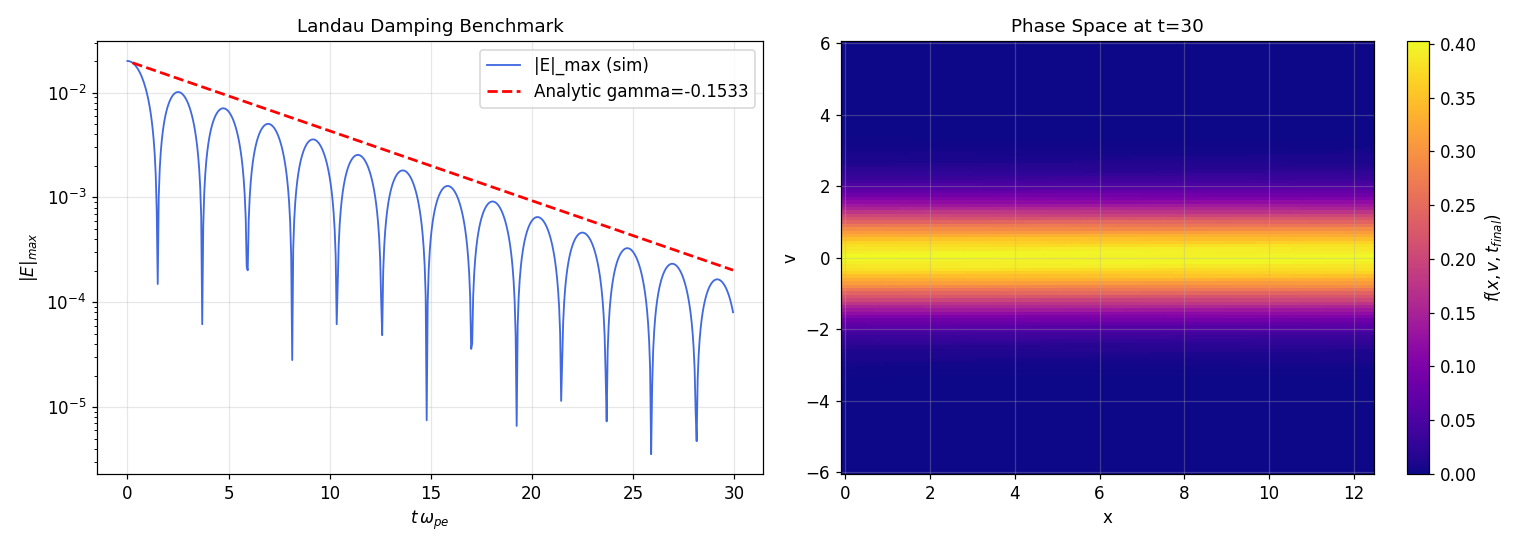

In [ ]:
Emax_hist, t_hist = [], []

for n in range(Nt):
    E = solve_poisson(f, v, x)
    Emax_hist.append(np.max(np.abs(E)))
    t_hist.append(n*dt)
    f = advect_x(f, v, dt/2, x)
    E = solve_poisson(f, v, x)
    f = advect_v(f, E, dt, v)
    f = advect_x(f, v, dt/2, x)
    if n % 150 == 0:
        print(f"  t={n*dt:6.1f}   |E|={Emax_hist[-1]:.4e}")
print("Done.")


### Computation 9c — Results: Decay Rate & Phase Space

In [ ]:
t_arr = np.array(t_hist)
Emax  = np.array(Emax_hist)

gamma_L = -0.1533
t_fit   = t_arr[5:]
E_fit   = Emax[5]*np.exp(gamma_L*(t_fit-t_arr[5]))

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].semilogy(t_arr, Emax, color='royalblue', lw=1.2, label='|E|_max (sim)')
axes[0].semilogy(t_fit, E_fit, 'r--', lw=1.8,
                 label=f'Analytic gamma={gamma_L}')
axes[0].set_xlabel(r'$t\,\omega_{pe}$'); axes[0].set_ylabel(r'$|E|_{max}$')
axes[0].set_title('Landau Damping Benchmark'); axes[0].legend()

im = axes[1].pcolormesh(X0, V0, f, cmap='plasma', shading='auto')
plt.colorbar(im, ax=axes[1], label=r'$f(x,v,t_{final})$')
axes[1].set_xlabel('x'); axes[1].set_ylabel('v')
axes[1].set_title(f'Phase Space at t={Nt*dt:.0f} (filamentation visible)')
plt.tight_layout(); plt.show()


  t=   0.0  |E|=4.0002e-02
  t=  10.0  |E|=6.3248e-02
  t=  20.0  |E|=1.0231e-01
  t=  30.0  |E|=3.4901e-01
Done.


---
## §10 — Two-Stream Instability

Two warm electron beams at $\pm v_0$ relative to fixed ions.
Modes with $k < k_c=\omega_{pe}/(\sqrt{2}\,v_0)$ grow exponentially.
Nonlinear saturation: a large BGK-like phase-space vortex forms.

### Computation 10 — Two-Stream Simulation

In [ ]:
Nx2, Nv2   = 64, 256
Lx2, vmax2  = 4*np.pi, 5.0
dt2, Nt2    = 0.05, 800
v0, vth2    = 1.5, 0.3
eps2, k2    = 0.02, 0.5

x2 = np.linspace(0, Lx2, Nx2, endpoint=False)
v2 = np.linspace(-vmax2, vmax2, Nv2)
X2, V2 = np.meshgrid(x2, v2, indexing='ij')

f2 = ((np.exp(-(V2-v0)**2/(2*vth2**2)) +
       np.exp(-(V2+v0)**2/(2*vth2**2)))/(2*np.sqrt(2*np.pi)*vth2)
     )*(1+eps2*np.cos(k2*X2))

Em2, t2 = [], []
for n in range(Nt2):
    E2 = solve_poisson(f2, v2, x2)
    Em2.append(np.max(np.abs(E2))); t2.append(n*dt2)
    f2 = advect_x(f2, v2, dt2/2, x2)
    E2 = solve_poisson(f2, v2, x2)
    f2 = advect_v(f2, E2, dt2, v2)
    f2 = advect_x(f2, v2, dt2/2, x2)
    if n % 200 == 0: print(f"  t={n*dt2:6.1f}  |E|={Em2[-1]:.4e}")
t2 = np.array(t2); Em2 = np.array(Em2)

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].semilogy(t2, Em2, color='darkorange', lw=1.2)
axes[0].set_xlabel(r'$t\,\omega_{pe}$'); axes[0].set_ylabel(r'$|E|_{max}$')
axes[0].set_title('Two-Stream: Growth & Saturation')

im2 = axes[1].pcolormesh(X2, V2, f2, cmap='inferno', shading='auto')
plt.colorbar(im2, ax=axes[1], label=r'$f(x,v)$')
axes[1].set_xlabel('x'); axes[1].set_ylabel('v')
axes[1].set_title('Phase-Space Vortex at Saturation (BGK state)')
plt.tight_layout(); plt.show()


---
## §11 — Bump-on-Tail Instability

A weak fast beam on top of a warm background:

$$f_0(v) = \frac{1-n_b}{\sqrt{2\pi}}e^{-v^2/2}+\frac{n_b}{\sqrt{2\pi}\sigma_b}e^{-(v-v_b)^2/(2\sigma_b^2)}$$

Because $\partial f_0/\partial v>0$ at $v_b$, waves resonant there grow exponentially
(inverse Landau damping / beam-plasma instability).

### Computation 11 — Bump-on-Tail Distribution & Instability Region

In [ ]:
v = np.linspace(-5, 8, 800)
nb, vb, sb = 0.1, 3.5, 0.4

f_bg   = (1-nb)*np.exp(-v**2/2)/np.sqrt(2*np.pi)
f_beam = nb*np.exp(-(v-vb)**2/(2*sb**2))/(np.sqrt(2*np.pi)*sb)
f_bot  = f_bg + f_beam
df_bot = np.gradient(f_bot, v)

fig, axes = plt.subplots(1,2,figsize=(13,4))
axes[0].plot(v, np.exp(-v**2/2)/np.sqrt(2*np.pi), 'k--', lw=1.5, label='Pure Maxwellian')
axes[0].plot(v, f_bg,  'b-', lw=1.5, label='Background')
axes[0].plot(v, f_beam,'r-', lw=1.5, label=f'Beam (nb={nb}, vb={vb})')
axes[0].plot(v, f_bot, 'g-', lw=2.5, label='Total (bump-on-tail)')
axes[0].set_xlabel(r'$v/v_{th}$'); axes[0].set_ylabel(r'$f_0(v)$')
axes[0].set_title('Bump-on-Tail Distribution'); axes[0].legend(fontsize=8)

axes[1].plot(v, df_bot, 'm-', lw=1.8, label=r"$\partial f_0/\partial v$")
axes[1].axhline(0, color='k', lw=0.8)
axes[1].fill_between(v, df_bot, 0, where=df_bot>0, alpha=0.35, color='red',
                     label='Unstable region')
axes[1].axvline(vb, color='orange', ls='--', label=f'Beam vb={vb}')
axes[1].set_xlabel(r'$v/v_{th}$'); axes[1].set_ylabel(r'$\partial f_0/\partial v$')
axes[1].set_title('Slope: Positive = Instability'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

k_wave = 0.5
slope_at = float(np.interp(1/k_wave, v, df_bot))
print(f"df/dv at v_phase={1/k_wave:.1f}: {slope_at:.4f}")
print(f"Rough growth rate: {np.pi/2*(1/k_wave)**2*slope_at:.4f} (omega_pe units)")


---
## Summary

| Topic | Core Result |
|-------|-------------|
| Vlasov equation | $df/dt=0$ — phase-space incompressible (Liouville) |
| Debye screening | $\lambda_D$ sets screening length; $\Lambda\gg1$ validates mean-field |
| Bohm-Gross | $\omega^2=\omega_{pe}^2+3k^2v_{th}^2$ — thermal correction to Langmuir waves |
| Landau damping | $\partial f_0/\partial v<0$ at $v_\phi$ → wave decays without collisions |
| BGK / Schamel | Exact nonlinear equilibria; phase-space holes are stable attractors |
| Moment closure | Infinite hierarchy; no truncation without collisions |
| Hammett-Perkins | $|k_\parallel|$ Fourier operator mimics Landau damping in fluid model |
| PIC noise | $\propto1/\sqrt{N}$ — degrades kinetic resonance studies |
| Semi-Lagrangian | Noise-free, CFL-unconditional, traces characteristics backward |
| Two-stream | Exponential growth → BGK vortex at saturation |
| Bump-on-tail | Positive slope → inverse Landau damping / beam instability |

**Key references:** Cheng & Knorr (1976), Hammett & Perkins (1990), Schamel (1986), BGK (1957).
